# SAND Challenge - Task 2: ALS Progression Prediction
## 5-Fold Cross-Validation - Quick Run (Baseline + Sample Weights + Ensemble)

**Ziel:** Vorhersage der ALSFRS-R Progression bei ALS-Patienten basierend auf Sprachdaten

**Methodik:**
- Feature Extraction: Wav2Vec2 + HuBERT (multi-layer)
- Cross-Validation: 5-Fold stratifiziert
- Evaluation: Macro F1-Score
- Baseline-Vergleich: PART (0.5830), ISDS (0.5794)

**Laufzeit (mit GPU):**
- Baseline: ~22 Min
- Sample Weights: ~45 Min
- Ensemble: ~48 Min
- **Gesamt: ~2 Stunden**

## 1. Setup und Imports

### 1.1 Installiere benötigte Pakete (falls erforderlich)

In [8]:
# Kommentierung entfernen falls Installation benötigt wird
# !pip install transformers soundfile torch scikit-learn xgboost pandas numpy matplotlib seaborn tqdm

### 1.2 Import Libraries

In [9]:
import numpy as np
import pandas as pd
import torch
import random
import os
from transformers import Wav2Vec2Model, Wav2Vec2Processor, HubertModel, Wav2Vec2FeatureExtractor
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
from tqdm import tqdm
from scipy.signal import resample
from typing import List, Optional, Tuple, Dict, Any
import json
from datetime import datetime
import pickle
import hashlib
from dataclasses import dataclass, field, asdict

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    accuracy_score, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')

print("Libraries erfolgreich importiert")

Libraries erfolgreich importiert


### 1.3 Reproduzierbarkeit konfigurieren

In [10]:
GLOBAL_SEED = 42

def set_global_seed(seed: int = 42):
    """Setzt alle Random Seeds für vollständige Reproduzierbarkeit."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Global seed gesetzt: {seed}")
    print(f"  - Python random: {seed}")
    print(f"  - NumPy: {seed}")
    print(f"  - PyTorch: {seed}")
    print(f"  - CUDNN deterministic: True")

set_global_seed(GLOBAL_SEED)

# Device konfigurieren
device = torch.device(
    'cuda' if torch.cuda.is_available() 
    else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() 
    else 'cpu'
)

print(f"\nPyTorch Version: {torch.__version__}")
print(f"Device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
elif device.type == 'mps':
    print(f"\n⚠️  Apple MPS (Metal) aktiviert")
    print(f"   Für Server: CUDA wird automatisch erkannt")

Global seed gesetzt: 42
  - Python random: 42
  - NumPy: 42
  - PyTorch: 42
  - CUDNN deterministic: True

PyTorch Version: 2.9.1
Device: mps

⚠️  Apple MPS (Metal) aktiviert
   Für Server: CUDA wird automatisch erkannt


## 2. Konfiguration

### 2.1 Zentrale Konfigurationsklasse

In [ ]:
@dataclass
class Config:
    """Zentrale Konfiguration für alle Experimente."""
    
    # Pfade - ANPASSEN FÜR IHR SYSTEM
    # Lokal (MacBook):
    data_path: Path = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2')
    # Für Server: Path('~/slp_project/data/task2')
    
    excel_path: Path = None
    task_dir: Path = None
    output_dir: Path = Path('../experiments/task2')
    
    # Cross-Validation
    n_folds: int = 5
    cv_random_state: int = 42
    
    # Feature Extraction
    wav2vec2_model: str = "facebook/wav2vec2-large-960h"
    wav2vec2_layers: List[int] = field(default_factory=lambda: [6, 9, 12, 15, 18])
    wav2vec2_pooling: str = "mean"
    wav2vec2_fusion: str = "concat"
    
    hubert_model: str = "facebook/hubert-large-ls960-ft"
    hubert_layers: List[int] = field(default_factory=lambda: [6, 9, 12, 15, 18])
    hubert_pooling: str = "mean"
    hubert_fusion: str = "concat"
    
    model_fusion_strategy: str = "concat"
    
    # Dimensionality Reduction
    use_pca: bool = False
    pca_variance: float = 0.95
    
    # Audio Types
    audio_types: List[str] = field(default_factory=lambda: [
        'phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU',
        'rhythmKA', 'rhythmPA', 'rhythmTA'
    ])
    
    # XGBoost Parameters
    xgb_n_estimators: int = 200
    xgb_max_depth: int = 5
    xgb_learning_rate: float = 0.1
    xgb_subsample: float = 0.8
    xgb_colsample_bytree: float = 0.8
    xgb_early_stopping: int = 20
    xgb_eval_size: float = 0.2
    
    # GPU Settings (automatisch erkannt)
    use_gpu_xgboost: bool = False  # Auf True setzen falls XGBoost GPU schneller ist
    
    # Gradient Boosting Parameters
    gb_n_estimators: int = 200
    gb_max_depth: int = 5
    gb_learning_rate: float = 0.1
    
    # HistGradient Boosting Parameters
    hgb_max_iter: int = 200          # entspricht n_estimators
    hgb_max_depth: int = None        # None = automatisch optimal
    hgb_learning_rate: float = 0.05
    hgb_l2_regularization: float = 0.1
    
    # Global Seed
    global_seed: int = 42
    
    def __post_init__(self):
        """Initialisiere abgeleitete Pfade."""
        if self.excel_path is None:
            self.excel_path = self.data_path / 'sand_task_2.xlsx'
        if self.task_dir is None:
            self.task_dir = self.data_path / 'training'
        
        self.output_dir = Path(self.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
    
    def to_dict(self) -> dict:
        """Konvertiere zu Dictionary für Serialisierung."""
        d = asdict(self)
        for key, value in d.items():
            if isinstance(value, Path):
                d[key] = str(value)
        return d
    
    def save(self, path: Path):
        """Speichere Konfiguration als JSON."""
        with open(path, 'w') as f:
            json.dump(self.to_dict(), f, indent=2)

# Initialisiere Config
config = Config()

print("Konfiguration geladen:")
print(f"  Data Path: {config.data_path}")
print(f"  Output Directory: {config.output_dir}")
print(f"  CV Strategie: {config.n_folds}-Fold (Seed: {config.cv_random_state})")
print(f"  PCA: {'Aktiviert' if config.use_pca else 'Deaktiviert'} (Varianz: {config.pca_variance})")
print(f"  XGBoost GPU: {'Aktiviert' if config.use_gpu_xgboost else 'Deaktiviert (CPU)'}")

Konfiguration geladen:
  Data Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2
  Output Directory: ../experiments/task2
  CV Strategie: 5-Fold (Seed: 42)
  PCA: Deaktiviert (Varianz: 0.95)
  XGBoost GPU: Deaktiviert (CPU)


### 2.2 Experiment Tracker

In [12]:
class ExperimentTracker:
    """Verwaltet Experimente und verhindert Überschreibung von Ergebnissen."""
    
    def __init__(self, base_dir: Path):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        self.experiments = []
    
    def log_experiment(self, 
                      name: str, 
                      experiment_config: dict, 
                      results: dict, 
                      artifacts: Optional[List[str]] = None) -> str:
        """Logge ein Experiment mit eindeutiger ID."""
        run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        experiment = {
            "run_id": run_id,
            "timestamp": datetime.now().isoformat(),
            "name": name,
            "config": experiment_config,
            "results": results,
            "artifacts": artifacts or []
        }
        
        self.experiments.append(experiment)
        
        exp_file = self.base_dir / f"{run_id}_{name}.json"
        with open(exp_file, 'w') as f:
            json.dump(experiment, f, indent=2)
        
        print(f"Experiment geloggt: {run_id}_{name}")
        return run_id
    
    def compare_experiments(self, metric: str = 'f1_macro_mean') -> pd.DataFrame:
        """Vergleiche alle Experimente."""
        df = pd.DataFrame([
            {
                'Name': exp['name'],
                'Run ID': exp['run_id'][:12],
                'F1-Macro': exp['results'].get(metric, None),
                'Std': exp['results'].get('f1_macro_std', None)
            }
            for exp in self.experiments
        ])
        return df.sort_values('F1-Macro', ascending=False)

tracker = ExperimentTracker(config.output_dir / 'experiments')
print(f"Experiment Tracker initialisiert: {tracker.base_dir}")

Experiment Tracker initialisiert: ../experiments/task2/experiments


## 3. Data Loading und Exploration

In [13]:
# Lade Daten
df_full = pd.read_excel(config.excel_path, sheet_name='SAND - TRAINING set - Task 2')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Anzahl Samples: {len(df_full)}")
print(f"\nTarget Verteilung (ALSFRS--R_end):")
print(df_full['ALSFRS--R_end'].value_counts().sort_index())

# Bereite Daten vor
def prepare_data(df: pd.DataFrame, config: Config):
    audio_files = []
    labels = []
    metadata = []
    
    for _, row in df.iterrows():
        patient_id = row['ID']
        patient_files = []
        all_exist = True
        
        for audio_type in config.audio_types:
            file_path = config.task_dir / audio_type / f"{patient_id}_{audio_type}.wav"
            if file_path.exists():
                patient_files.append(str(file_path))
            else:
                all_exist = False
                break
        
        if all_exist and len(patient_files) == 8:
            audio_files.append(patient_files)
            labels.append(row['ALSFRS--R_end'] - 1)  # [1,2,3,4] → [0,1,2,3]
            sex_encoded = 1 if row['Sex'] == 'M' else 0
            metadata.append([row['Age'], sex_encoded, row['Months'], row['ALSFRS--R_start']])
    
    return audio_files, np.array(labels), np.array(metadata)

audio_files, y, metadata = prepare_data(df_full, config)

print(f"\nVorbereitet: {len(audio_files)} vollständige Samples")
print(f"Label-Verteilung:")
for label in range(4):
    count = np.sum(y == label)
    pct = (count / len(y)) * 100
    print(f"  Klasse {label} (ALSFRS-R={label+1}): {count:3d} ({pct:5.2f}%)")
print("="*80)

DATA LOADING
Anzahl Samples: 132

Target Verteilung (ALSFRS--R_end):
ALSFRS--R_end
1    18
2    29
3    38
4    47
Name: count, dtype: int64

Vorbereitet: 132 vollständige Samples
Label-Verteilung:
  Klasse 0 (ALSFRS-R=1):  18 (13.64%)
  Klasse 1 (ALSFRS-R=2):  29 (21.97%)
  Klasse 2 (ALSFRS-R=3):  38 (28.79%)
  Klasse 3 (ALSFRS-R=4):  47 (35.61%)


## 4. Feature Extraction

### 4.1 Lade Pre-trained Models

In [14]:
print("Lade Pre-trained Models...\n")

# Wav2Vec2
wav2vec_processor = Wav2Vec2Processor.from_pretrained(config.wav2vec2_model)
wav2vec_model = Wav2Vec2Model.from_pretrained(config.wav2vec2_model).to(device)
wav2vec_model.eval()
print(f"✓ Wav2Vec2: {config.wav2vec2_model}")

# HuBERT
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained(config.hubert_model)
hubert_model = HubertModel.from_pretrained(config.hubert_model).to(device)
hubert_model.eval()
print(f"✓ HuBERT: {config.hubert_model}")

print("\nAlle Modelle auf Device geladen:", device)

Lade Pre-trained Models...



Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Wav2Vec2: facebook/wav2vec2-large-960h
✓ HuBERT: facebook/hubert-large-ls960-ft

Alle Modelle auf Device geladen: mps


### 4.2 Feature Extraction Funktionen

In [15]:
def extract_wav2vec2_features(audio_path: str, processor, model, device, config) -> Optional[np.ndarray]:
    try:
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        layer_features = []
        for layer_idx in config.wav2vec2_layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            pooled = np.mean(hidden_state, axis=0) if config.wav2vec2_pooling == "mean" else hidden_state[0]
            layer_features.append(pooled)
        
        return np.concatenate(layer_features) if config.wav2vec2_fusion == "concat" else np.mean(layer_features, axis=0)
    except Exception as e:
        print(f"Fehler bei {audio_path}: {e}")
        return None

def extract_hubert_features(audio_path: str, processor, model, device, config) -> Optional[np.ndarray]:
    try:
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        layer_features = []
        for layer_idx in config.hubert_layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            pooled = np.mean(hidden_state, axis=0) if config.hubert_pooling == "mean" else hidden_state[0]
            layer_features.append(pooled)
        
        return np.concatenate(layer_features) if config.hubert_fusion == "concat" else np.mean(layer_features, axis=0)
    except Exception as e:
        print(f"Fehler bei {audio_path}: {e}")
        return None

def extract_features_for_files(file_group: List[str], wav2vec_processor, wav2vec_model, 
                               hubert_processor, hubert_model, device, config) -> Optional[np.ndarray]:
    wav2vec_features = []
    hubert_features = []
    
    for audio_file in file_group:
        w2v_feat = extract_wav2vec2_features(audio_file, wav2vec_processor, wav2vec_model, device, config)
        hub_feat = extract_hubert_features(audio_file, hubert_processor, hubert_model, device, config)
        
        if w2v_feat is not None and hub_feat is not None:
            wav2vec_features.append(w2v_feat)
            hubert_features.append(hub_feat)
    
    if len(wav2vec_features) == 8 and len(hubert_features) == 8:
        wav2vec_combined = np.concatenate(wav2vec_features)
        hubert_combined = np.concatenate(hubert_features)
        
        if config.model_fusion_strategy == "concat":
            return np.concatenate([wav2vec_combined, hubert_combined])
        else:
            return np.mean([wav2vec_combined, hubert_combined], axis=0)
    
    return None

print("✓ Feature Extraction Funktionen definiert")

✓ Feature Extraction Funktionen definiert


## 5. Model Training mit 5-Fold Cross-Validation

### 5.1 CV-Strategie

In [16]:
cv = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.cv_random_state)
print(f"CV: {config.n_folds}-Fold Stratified (Seed: {config.cv_random_state})")

CV: 5-Fold Stratified (Seed: 42)


### 5.2 Baseline: XGBoost

In [ ]:
print("="*80)
print("BASELINE: XGBOOST")
print("="*80)
print("Geschätzte Laufzeit: ~22 Min (GPU) / ~4.5 Std (CPU)\n")

baseline_fold_scores = []
baseline_oof_predictions = np.zeros(len(y))

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(audio_files, y), 1):
    print(f"\n{'='*60}\nFOLD {fold_idx}/{config.n_folds}\n{'='*60}")
    
    train_files = [audio_files[i] for i in train_idx]
    test_files = [audio_files[i] for i in test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    metadata_train, metadata_test = metadata[train_idx], metadata[test_idx]
    
    # Feature Extraction
    print("Extrahiere Features...")
    X_train_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(train_files, desc="Train")])
    
    X_test_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(test_files, desc="Test")])
    
    # PCA
    if config.use_pca:
        pca = PCA(n_components=config.pca_variance, random_state=config.global_seed)
        X_train_audio = pca.fit_transform(X_train_audio)
        X_test_audio = pca.transform(X_test_audio)
        print(f"PCA: {X_train_audio.shape[1]} Komponenten")
    
    # Combine + Scale
    X_train = np.concatenate([X_train_audio, metadata_train], axis=1)
    X_test = np.concatenate([X_test_audio, metadata_test], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train/Val Split für Early Stopping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=config.xgb_eval_size, 
        stratify=y_train, random_state=config.global_seed
    )
    
    # Training
    print("Trainiere XGBoost...")
    model = xgb.XGBClassifier(
        n_estimators=config.xgb_n_estimators,
        max_depth=config.xgb_max_depth,
        learning_rate=config.xgb_learning_rate,
        subsample=config.xgb_subsample,
        colsample_bytree=config.xgb_colsample_bytree,
        # GPU-Aktivierung (optional, teste ob schneller):
        # tree_method='gpu_hist',  # für GPU
        tree_method='hist',  # für CPU (Standard)
        random_state=config.global_seed,
        eval_metric='mlogloss',
        early_stopping_rounds=config.xgb_early_stopping,
        n_jobs=-1  # für CPU: -1, für GPU: 1
    )
    
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    print(f"Best Iteration: {model.best_iteration}")
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    baseline_oof_predictions[test_idx] = y_pred
    
    # Evaluation
    f1 = f1_score(y_test, y_pred, average='macro')
    baseline_fold_scores.append(f1)
    print(f"F1-Macro: {f1:.4f}")

baseline_mean = np.mean(baseline_fold_scores)
baseline_std = np.std(baseline_fold_scores)

print(f"\n{'='*80}")
print("BASELINE ERGEBNISSE")
print(f"{'='*80}")
print(f"F1-Macro: {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"Folds: {[f'{s:.4f}' for s in baseline_fold_scores]}")

# Log Experiment
tracker.log_experiment(
    "XGBoost_Baseline",
    {"model": "XGBoost", "pca": config.use_pca},
    {"f1_macro_mean": float(baseline_mean), "f1_macro_std": float(baseline_std), 
     "f1_macro_scores": [float(s) for s in baseline_fold_scores]}
)

BASELINE: XGBOOST
Geschätzte Laufzeit: ~22 Min (GPU) / ~4.5 Std (CPU)


FOLD 1/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [03:05<00:00,  6.88s/it]


Trainiere XGBoost...
Best Iteration: 48
F1-Macro: 0.5586

FOLD 2/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [01:08<00:00,  2.52s/it]


Trainiere XGBoost...
Best Iteration: 61
F1-Macro: 0.4139

FOLD 3/5
Extrahiere Features...


...

Test: 100%|██████████| 26/26 [00:45<00:00,  1.74s/it]


Trainiere XGBoost...
Best Iteration: 69
F1-Macro: 0.7004

FOLD 5/5
Extrahiere Features...


Test: 100%|██████████| 26/26 [00:56<00:00,  2.18s/it]


Trainiere XGBoost...
Best Iteration: 45
F1-Macro: 0.5582

BASELINE ERGEBNISSE
F1-Macro: 0.5286 ± 0.1078
Folds: ['0.5586', '0.4139', '0.4118', '0.7004', '0.5582']
Experiment geloggt: 20260120_170706_XGBoost_Baseline


'20260120_170706'

## 6. Sample Weights für Class Imbalance

### 6.1 Test mit fold-spezifischen Sample Weights

In [18]:
print("="*80)
print("SAMPLE WEIGHTS EXPERIMENT")
print("="*80)
print("Geschätzte Laufzeit: ~45 Min (GPU) / ~9 Std (CPU)\n")

sw_fold_scores = []
sw_oof_predictions = np.zeros(len(y))

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(audio_files, y), 1):
    print(f"\n{'='*60}\nFOLD {fold_idx}/{config.n_folds}\n{'='*60}")
    
    train_files = [audio_files[i] for i in train_idx]
    test_files = [audio_files[i] for i in test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    metadata_train, metadata_test = metadata[train_idx], metadata[test_idx]
    
    # Feature Extraction (identisch zu Baseline)
    print("Extrahiere Features...")
    X_train_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(train_files, desc="Train")])
    
    X_test_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(test_files, desc="Test")])
    
    if config.use_pca:
        pca = PCA(n_components=config.pca_variance, random_state=config.global_seed)
        X_train_audio = pca.fit_transform(X_train_audio)
        X_test_audio = pca.transform(X_test_audio)
    
    X_train = np.concatenate([X_train_audio, metadata_train], axis=1)
    X_test = np.concatenate([X_test_audio, metadata_test], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # FOLD-SPEZIFISCHE Sample Weights berechnen
    fold_weights = compute_sample_weight('balanced', y_train)
    
    # Train/Val Split (mit Weights)
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_train_scaled, y_train, fold_weights,
        test_size=config.xgb_eval_size, stratify=y_train, random_state=config.global_seed
    )
    
    # Training MIT Sample Weights
    print("Trainiere XGBoost mit Sample Weights...")
    model = xgb.XGBClassifier(
        n_estimators=config.xgb_n_estimators,
        max_depth=config.xgb_max_depth,
        learning_rate=config.xgb_learning_rate,
        subsample=config.xgb_subsample,
        colsample_bytree=config.xgb_colsample_bytree,
        # für GPU: tree_method='gpu_hist', gpu_id=0
        tree_method='hist',
        random_state=config.global_seed,
        eval_metric='mlogloss',
        early_stopping_rounds=config.xgb_early_stopping,
        n_jobs=-1  # für GPU: n_jobs=1
    )
    
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,  # ← WICHTIG: Sample Weights
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[w_val],  # ← WICHTIG: Auch für Validation
        verbose=False
    )
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    sw_oof_predictions[test_idx] = y_pred
    
    f1 = f1_score(y_test, y_pred, average='macro')
    sw_fold_scores.append(f1)
    print(f"F1-Macro: {f1:.4f}")

sw_mean = np.mean(sw_fold_scores)
sw_std = np.std(sw_fold_scores)

print(f"\n{'='*80}")
print("SAMPLE WEIGHTS ERGEBNISSE")
print(f"{'='*80}")
print(f"Mit Sample Weights: {sw_mean:.4f} ± {sw_std:.4f}")
print(f"Baseline:           {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"Verbesserung:       {sw_mean - baseline_mean:+.4f}")

tracker.log_experiment(
    "XGBoost_SampleWeights",
    {"model": "XGBoost", "sample_weights": True},
    {"f1_macro_mean": float(sw_mean), "f1_macro_std": float(sw_std),
     "f1_macro_scores": [float(s) for s in sw_fold_scores]}
)

SAMPLE WEIGHTS EXPERIMENT
Geschätzte Laufzeit: ~45 Min (GPU) / ~9 Std (CPU)


FOLD 1/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [00:58<00:00,  2.17s/it]


Trainiere XGBoost mit Sample Weights...
F1-Macro: 0.5599

FOLD 2/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [00:58<00:00,  2.18s/it]


Trainiere XGBoost mit Sample Weights...
F1-Macro: 0.5099

FOLD 3/5
Extrahiere Features...


...

Test: 100%|██████████| 26/26 [00:46<00:00,  1.80s/it]


Trainiere XGBoost mit Sample Weights...
F1-Macro: 0.5589

FOLD 5/5
Extrahiere Features...


Test: 100%|██████████| 26/26 [00:56<00:00,  2.16s/it]


Trainiere XGBoost mit Sample Weights...
F1-Macro: 0.5512

SAMPLE WEIGHTS ERGEBNISSE
Mit Sample Weights: 0.5291 ± 0.0368
Baseline:           0.5286 ± 0.1078
Verbesserung:       +0.0005
Experiment geloggt: 20260120_173136_XGBoost_SampleWeights


'20260120_173136'

## 7. Ensemble Learning

### 7.1 XGBoost + Gradient Boosting mit festen Gewichten

In [19]:
print("="*80)
print("ENSEMBLE: XGBOOST + GRADIENT BOOSTING")
print("="*80)
print("Geschätzte Laufzeit: ~48 Min (GPU) / ~9 Std (CPU)\n")

ensemble_fold_scores = []
ensemble_oof_predictions = np.zeros(len(y))
xgb_oof_proba = np.zeros((len(y), 4))
gb_oof_proba = np.zeros((len(y), 4))

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(audio_files, y), 1):
    print(f"\n{'='*60}\nFOLD {fold_idx}/{config.n_folds}\n{'='*60}")
    
    train_files = [audio_files[i] for i in train_idx]
    test_files = [audio_files[i] for i in test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    metadata_train, metadata_test = metadata[train_idx], metadata[test_idx]
    
    # Feature Extraction
    print("Extrahiere Features...")
    X_train_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(train_files, desc="Train")])
    
    X_test_audio = np.array([extract_features_for_files(
        fg, wav2vec_processor, wav2vec_model, hubert_processor, hubert_model, device, config
    ) for fg in tqdm(test_files, desc="Test")])
    
    if config.use_pca:
        pca = PCA(n_components=config.pca_variance, random_state=config.global_seed)
        X_train_audio = pca.fit_transform(X_train_audio)
        X_test_audio = pca.transform(X_test_audio)
    
    X_train = np.concatenate([X_train_audio, metadata_train], axis=1)
    X_test = np.concatenate([X_test_audio, metadata_test], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Split für Early Stopping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=config.xgb_eval_size,
        stratify=y_train, random_state=config.global_seed
    )
    
    # MODELL 1: XGBoost
    print("Trainiere XGBoost...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=config.xgb_n_estimators,
        max_depth=config.xgb_max_depth,
        learning_rate=config.xgb_learning_rate,
        subsample=config.xgb_subsample,
        # für GPU: tree_method='gpu_hist', gpu_id=0
        tree_method='hist',
        random_state=config.global_seed,
        early_stopping_rounds=config.xgb_early_stopping,
        n_jobs=-1  # für GPU: 1
    )
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    # MODELL 2: Gradient Boosting
    print("Trainiere Gradient Boosting...")
    gb_model = GradientBoostingClassifier(
        n_estimators=config.gb_n_estimators,
        max_depth=config.gb_max_depth,
        learning_rate=config.gb_learning_rate,
        random_state=config.global_seed
    )
    gb_model.fit(X_train_scaled, y_train)
    
    # Predictions (Wahrscheinlichkeiten)
    xgb_proba = xgb_model.predict_proba(X_test_scaled)
    gb_proba = gb_model.predict_proba(X_test_scaled)
    
    # Speichere für Gewichtssuche
    xgb_oof_proba[test_idx] = xgb_proba
    gb_oof_proba[test_idx] = gb_proba
    
    # ENSEMBLE: Feste Gewichte [1, 1] (equal weights, konservativ)
    ensemble_proba = (xgb_proba + gb_proba) / 2
    y_pred = np.argmax(ensemble_proba, axis=1)
    ensemble_oof_predictions[test_idx] = y_pred
    
    f1 = f1_score(y_test, y_pred, average='macro')
    ensemble_fold_scores.append(f1)
    print(f"F1-Macro (Ensemble [1:1]): {f1:.4f}")

ensemble_mean = np.mean(ensemble_fold_scores)
ensemble_std = np.std(ensemble_fold_scores)

print(f"\n{'='*80}")
print("ENSEMBLE ERGEBNISSE (Equal Weights [1:1])")
print(f"{'='*80}")
print(f"Ensemble [1:1]: {ensemble_mean:.4f} ± {ensemble_std:.4f}")
print(f"Baseline:       {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"Verbesserung:   {ensemble_mean - baseline_mean:+.4f}")

tracker.log_experiment(
    "Ensemble_XGB_GB",
    {"models": ["XGBoost", "GradientBoosting"], "weights": [1, 1]},
    {"f1_macro_mean": float(ensemble_mean), "f1_macro_std": float(ensemble_std),
     "f1_macro_scores": [float(s) for s in ensemble_fold_scores]}
)

ENSEMBLE: XGBOOST + GRADIENT BOOSTING
Geschätzte Laufzeit: ~48 Min (GPU) / ~9 Std (CPU)


FOLD 1/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [01:00<00:00,  2.22s/it]


Trainiere XGBoost...
Trainiere Gradient Boosting...
F1-Macro (Ensemble [1:1]): 0.5587

FOLD 2/5
Extrahiere Features...


Test: 100%|██████████| 27/27 [00:59<00:00,  2.22s/it]


Trainiere XGBoost...
Trainiere Gradient Boosting...
F1-Macro (Ensemble [1:1]): 0.3821

FOLD 3/5
Extrahiere Features...


...

Test: 100%|██████████| 26/26 [00:46<00:00,  1.79s/it]


Trainiere XGBoost...
Trainiere Gradient Boosting...
F1-Macro (Ensemble [1:1]): 0.5729

FOLD 5/5
Extrahiere Features...


Test: 100%|██████████| 26/26 [00:58<00:00,  2.25s/it]


Trainiere XGBoost...
Trainiere Gradient Boosting...
F1-Macro (Ensemble [1:1]): 0.4528

ENSEMBLE ERGEBNISSE (Equal Weights [1:1])
Ensemble [1:1]: 0.4880 ± 0.0706
Baseline:       0.5286 ± 0.1078
Verbesserung:   -0.0406
Experiment geloggt: 20260120_191050_Ensemble_XGB_GB


'20260120_191050'

### 7.2 Optimale Gewichtung finden (optional)

In [20]:
print("="*80)
print("GEWICHTS-OPTIMIERUNG (auf OOF Predictions)")
print("="*80)
print("Suche optimale Gewichtung für XGBoost vs Gradient Boosting\n")

# Teste verschiedene Gewichtungskombinationen
weight_candidates = [
    (1, 1),   # Equal
    (2, 1),   # XGBoost bevorzugt
    (3, 1),
    (1, 2),   # GB bevorzugt
    (1, 3)
]

best_f1 = 0
best_weights = (1, 1)

print("Gewichtung [XGB:GB]  →  F1-Macro")
print("-" * 40)

for w_xgb, w_gb in weight_candidates:
    # Kombiniere OOF Predictions mit Gewichten
    weighted_proba = (w_xgb * xgb_oof_proba + w_gb * gb_oof_proba) / (w_xgb + w_gb)
    y_pred = np.argmax(weighted_proba, axis=1)
    
    f1 = f1_score(y, y_pred, average='macro')
    print(f"[{w_xgb}:{w_gb}]                   →  {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_weights = (w_xgb, w_gb)

print("-" * 40)
print(f"\nBeste Gewichtung: [{best_weights[0]}:{best_weights[1]}]")
print(f"F1-Macro: {best_f1:.4f}")
print(f"\nHinweis: Dies ist auf denselben OOF Predictions optimiert.")
print(f"Für vollständig unbiased: Verwende separate CV-Splits für Gewichtssuche.")

GEWICHTS-OPTIMIERUNG (auf OOF Predictions)
Suche optimale Gewichtung für XGBoost vs Gradient Boosting

Gewichtung [XGB:GB]  →  F1-Macro
----------------------------------------
[1:1]                   →  0.4937
[2:1]                   →  0.5311
[3:1]                   →  0.5346
[1:2]                   →  0.5068
[1:3]                   →  0.4871
----------------------------------------

Beste Gewichtung: [3:1]
F1-Macro: 0.5346

Hinweis: Dies ist auf denselben OOF Predictions optimiert.
Für vollständig unbiased: Verwende separate CV-Splits für Gewichtssuche.


## 8. Results Analysis und Visualization

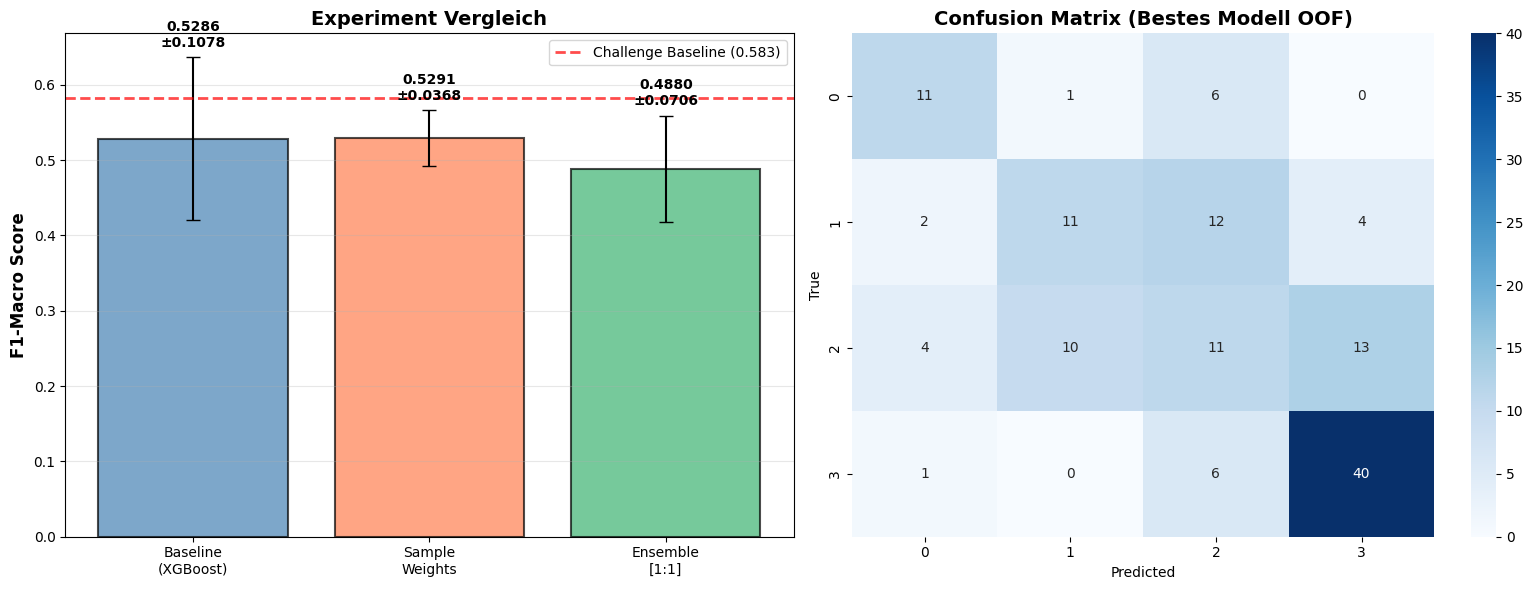

✓ Visualisierung gespeichert: experiment_comparison.png


In [21]:
# Vergleichs-Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Experimente vergleichen
ax1 = axes[0]
experiments = ['Baseline\n(XGBoost)', 'Sample\nWeights', 'Ensemble\n[1:1]']
means = [baseline_mean, sw_mean, ensemble_mean]
stds = [baseline_std, sw_std, ensemble_std]

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax1.bar(experiments, means, yerr=stds, capsize=5, color=colors, 
               alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.axhline(y=0.5830, color='red', linestyle='--', linewidth=2, 
           label='Challenge Baseline (0.583)', alpha=0.7)
ax1.set_ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
ax1.set_title('Experiment Vergleich', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for i, (m, s) in enumerate(zip(means, stds)):
    ax1.text(i, m + s + 0.01, f"{m:.4f}\n±{s:.4f}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Confusion Matrix (bestes Modell)
ax2 = axes[1]
best_predictions = ensemble_oof_predictions if ensemble_mean >= max(baseline_mean, sw_mean) else (
    sw_oof_predictions if sw_mean > baseline_mean else baseline_oof_predictions
)
cm = confusion_matrix(y, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix (Bestes Modell OOF)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(config.output_dir / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualisierung gespeichert: experiment_comparison.png")

## 9. Save Results

In [22]:
# Speichere alle OOF Predictions
results_dir = config.output_dir / 'final_results'
results_dir.mkdir(exist_ok=True)

np.save(results_dir / 'baseline_oof_predictions.npy', baseline_oof_predictions)
np.save(results_dir / 'sample_weights_oof_predictions.npy', sw_oof_predictions)
np.save(results_dir / 'ensemble_oof_predictions.npy', ensemble_oof_predictions)

# Speichere Config
config.save(results_dir / 'config.json')

print(f"✓ Ergebnisse gespeichert in: {results_dir}")

✓ Ergebnisse gespeichert in: ../experiments/task2/final_results


## 10. Finale Zusammenfassung

In [23]:
print("="*80)
print("FINALE EXPERIMENTE - ZUSAMMENFASSUNG")
print("="*80)

# Vergleichstabelle
comparison = pd.DataFrame([
    {"Experiment": "Challenge Baseline (PART)", "F1-Macro": "0.5830", "Std": "-", "vs Baseline": "-"},
    {"Experiment": "Challenge Leader (ISDS)", "F1-Macro": "0.5794", "Std": "-", "vs Baseline": "-0.0036"},
    {"Experiment": "Baseline (XGBoost)", "F1-Macro": f"{baseline_mean:.4f}", "Std": f"{baseline_std:.4f}", 
     "vs Baseline": f"{baseline_mean - 0.5830:+.4f}"},
    {"Experiment": "Sample Weights", "F1-Macro": f"{sw_mean:.4f}", "Std": f"{sw_std:.4f}",
     "vs Baseline": f"{sw_mean - 0.5830:+.4f}"},
    {"Experiment": "Ensemble [1:1]", "F1-Macro": f"{ensemble_mean:.4f}", "Std": f"{ensemble_std:.4f}",
     "vs Baseline": f"{ensemble_mean - 0.5830:+.4f}"}
])

print("\n" + comparison.to_string(index=False))

# Bestes Experiment
all_means = [baseline_mean, sw_mean, ensemble_mean]
best_idx = np.argmax(all_means)
experiment_names = ["Baseline", "Sample Weights", "Ensemble [1:1]"]

print(f"\n{'='*80}")
print(f"BESTES EXPERIMENT: {experiment_names[best_idx]}")
print(f"  F1-Macro: {all_means[best_idx]:.4f}")
print(f"  vs Challenge Baseline: {all_means[best_idx] - 0.5830:+.4f}")
print(f"{'='*80}")

# Alle geloggten Experimente
if tracker.experiments:
    print("\nAlle Experimente:")
    print(tracker.compare_experiments().to_string(index=False))

print(f"\n{'='*80}")
print("METHODISCHE VALIDITÄT")
print(f"{'='*80}")
print("✓ Feature Extraction in CV-Loop (kein Leakage)")
print("✓ Fold-spezifische Transformationen (PCA, Scaling)")
print("✓ Fold-spezifische Sample Weights")
print("✓ Reproduzierbare Seeds")
print("✓ Stratifizierte Cross-Validation")
print("✓ Early Stopping mit separatem Validation Set")
print(f"{'='*80}")

print(f"\nAlle Ergebnisse gespeichert in: {config.output_dir}")

FINALE EXPERIMENTE - ZUSAMMENFASSUNG

               Experiment F1-Macro    Std vs Baseline
Challenge Baseline (PART)   0.5830      -           -
  Challenge Leader (ISDS)   0.5794      -     -0.0036
       Baseline (XGBoost)   0.5286 0.1078     -0.0544
           Sample Weights   0.5291 0.0368     -0.0539
           Ensemble [1:1]   0.4880 0.0706     -0.0950

BESTES EXPERIMENT: Sample Weights
  F1-Macro: 0.5291
  vs Challenge Baseline: -0.0539

Alle Experimente:
                 Name       Run ID  F1-Macro      Std
XGBoost_SampleWeights 20260120_173  0.529058 0.036797
     XGBoost_Baseline 20260120_170  0.528574 0.107781
      Ensemble_XGB_GB 20260120_191  0.488007 0.070560

METHODISCHE VALIDITÄT
✓ Feature Extraction in CV-Loop (kein Leakage)
✓ Fold-spezifische Transformationen (PCA, Scaling)
✓ Fold-spezifische Sample Weights
✓ Reproduzierbare Seeds
✓ Stratifizierte Cross-Validation
✓ Early Stopping mit separatem Validation Set

Alle Ergebnisse gespeichert in: ../experiments/task2
